In [3]:
import pandas as pd

In [8]:
results_df =  pd.read_csv('C:\\Users\Ronza\Dev\DP-MSD\\amazon\\results\\results_from_server\Amazon_Matroid_Results.csv')

In [9]:
results_df.head()

,alg,k,eps,private,lambda_param,gamma,rep,value,relevance,diversity,queries,time_sec,timestamp
0,RandomBaseline,4,0.2,True,0.1,0.2,0,0.026846,0.010624,0.172838,1,0.0037,1771236648298
1,LocalSearch_Matroid,4,0.2,True,0.1,0.2,0,0.111293,0.086032,0.338642,305117,158.8610,1771236807159
2,DPSampleLocalSearch,4,0.2,True,0.1,0.2,0,0.111293,0.086032,0.338642,23002,290.8055,1771237097965
3,RandomBaseline,4,0.2,True,0.1,0.2,1,0.027738,0.004907,0.233212,23003,0.0019,1771237097966
4,DPSampleLocalSearch,4,0.2,True,0.1,0.2,1,0.111293,0.086032,0.338642,23002,289.1516,1771237387118


## Impact of k on score


In [10]:
results_df['alg'] = results_df['alg'].replace(
    {
        'LocalSearch_Matroid': 'LS',
        'DPSampleLocalSearch': 'DP-SLS',
        'RandomBaseline': 'Random'
    }
)

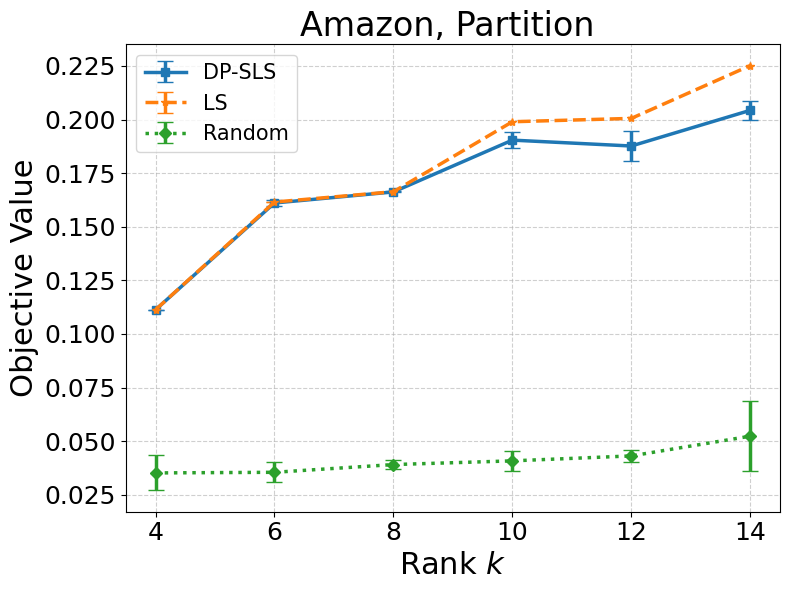

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(8, 6)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    plt.errorbar(
        alg_data['k'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  # Slightly thicker lines
        markersize=6,  # Larger markers for better visibility
        capsize=6       # Distinct caps for the error bars
    )

# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon, Partition ', fontsize=24)

plt.xticks(range(4,16,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_val.pdf')
plt.show()

## Impact of eps on score


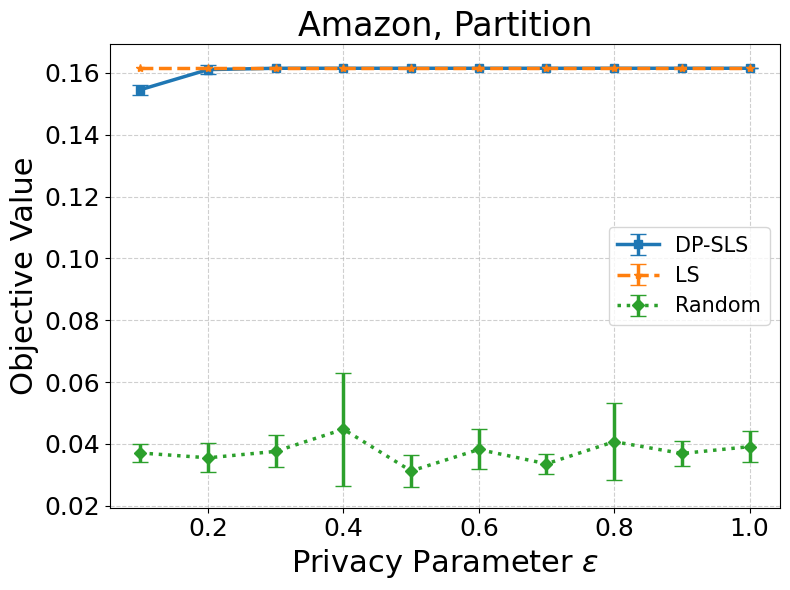

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6
eps_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(8, 6)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    plt.errorbar(
        alg_data['eps'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  
        markersize=6,   # Exact size from your reference
        capsize=6       
    )

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon, Partition', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(eps_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=15, frameon=True) # Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_matroid_eps_on_val.pdf')
plt.show()

## Impact of k on num queries

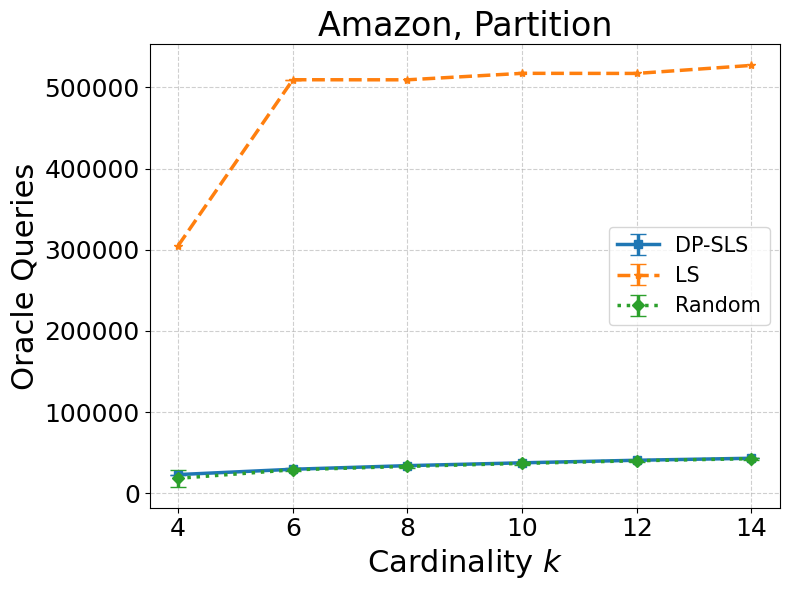

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(8, 6)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    plt.errorbar(
        alg_data['k'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  # Slightly thicker lines
        markersize=6,  # Larger markers for better visibility
        capsize=6       # Distinct caps for the error bars
    )

# Formatting for large text relative to the image size
plt.xlabel('Cardinality $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Amazon, Partition', fontsize=24)

plt.xticks(range(4,16,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_matroid_k_on_queries.pdf')
plt.show()

## Impact of k on execution time


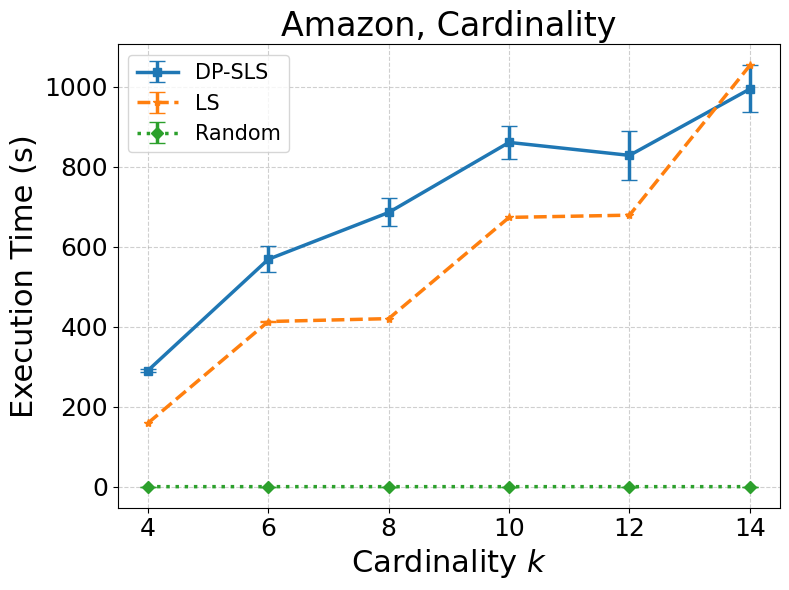

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.2) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(8, 6)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    plt.errorbar(
        alg_data['k'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  # Slightly thicker lines
        markersize=6,  # Larger markers for better visibility
        capsize=6       # Distinct caps for the error bars
    )

# Formatting for large text relative to the image size
plt.xlabel('Cardinality $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Amazon, Cardinality', fontsize=24)

plt.xticks(range(4,16,2), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_k_on_time.pdf')
plt.show()